## Part 1 — Import Libraries

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping

print('TensorFlow version:', tf.__version__)
print('GPU Available:', tf.config.list_physical_devices('GPU'))

TensorFlow version: 2.19.0
GPU Available: []


In [23]:
import os

print("Folders inside /kaggle/input:")
print(os.listdir("/kaggle/input"))

Folders inside /kaggle/input:
['datasets']


## Part 2 — Define Dataset Paths

In [29]:
import os

BASE_PATH = "/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images"

TRAIN_PATH = os.path.join(BASE_PATH, "train")
TEST_PATH = os.path.join(BASE_PATH, "test")
VAL_PATH = os.path.join(BASE_PATH, "validation")

print(TRAIN_PATH)
print(os.path.exists(TRAIN_PATH))

print(TEST_PATH)
print(os.path.exists(TEST_PATH))

print(VAL_PATH)
print(os.path.exists(VAL_PATH))

/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/train
True
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/test
True
/kaggle/input/datasets/misrakahmed/vegetable-image-dataset/Vegetable Images/validation
True


In [30]:
print(os.path.exists(TRAIN_PATH))
print(os.path.exists(TEST_PATH))
print(os.path.exists(VAL_PATH))

True
True
True


## Part 3 — Count Images in Each Class

In [31]:
def count_images(folder_path):
    counts = {}
    for class_name in sorted(os.listdir(folder_path)):
        class_dir = os.path.join(folder_path, class_name)
        if os.path.isdir(class_dir):
            counts[class_name] = len([
                f for f in os.listdir(class_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png'))
            ])
    return counts

train_counts = count_images(TRAIN_PATH)
test_counts  = count_images(TEST_PATH)
val_counts   = count_images(VAL_PATH)

print('=== Train Counts ===')
for cls, cnt in train_counts.items():
    print(f'  {cls:<20} {cnt}')

=== Train Counts ===
  Bean                 1000
  Bitter_Gourd         1000
  Bottle_Gourd         1000
  Brinjal              1000
  Broccoli             1000
  Cabbage              1000
  Capsicum             1000
  Carrot               1000
  Cauliflower          1000
  Cucumber             1000
  Papaya               1000
  Potato               1000
  Pumpkin              1000
  Radish               1000
  Tomato               1000


## Part 4 — Summary DataFrame

In [32]:
df = pd.DataFrame({
    'Vegetable':        list(train_counts.keys()),
    'Train Count':      list(train_counts.values()),
    'Test Count':       [test_counts.get(k, 0) for k in train_counts],
    'Validation Count': [val_counts.get(k, 0)  for k in train_counts],
})

df = df.set_index('Vegetable')

print('=== Dataset Summary ===')
print(df)
print(f'\nTotal Train:      {df["Train Count"].sum()}')
print(f'Total Test:       {df["Test Count"].sum()}')
print(f'Total Validation: {df["Validation Count"].sum()}')

=== Dataset Summary ===
              Train Count  Test Count  Validation Count
Vegetable                                              
Bean                 1000         200               200
Bitter_Gourd         1000         200               200
Bottle_Gourd         1000         200               200
Brinjal              1000         200               200
Broccoli             1000         200               200
Cabbage              1000         200               200
Capsicum             1000         200               200
Carrot               1000         200               200
Cauliflower          1000         200               200
Cucumber             1000         200               200
Papaya               1000         200               200
Potato               1000         200               200
Pumpkin              1000         200               200
Radish               1000         200               200
Tomato               1000         200               200

Total Train:      15000

## Part 5 — Visualize Class Distribution

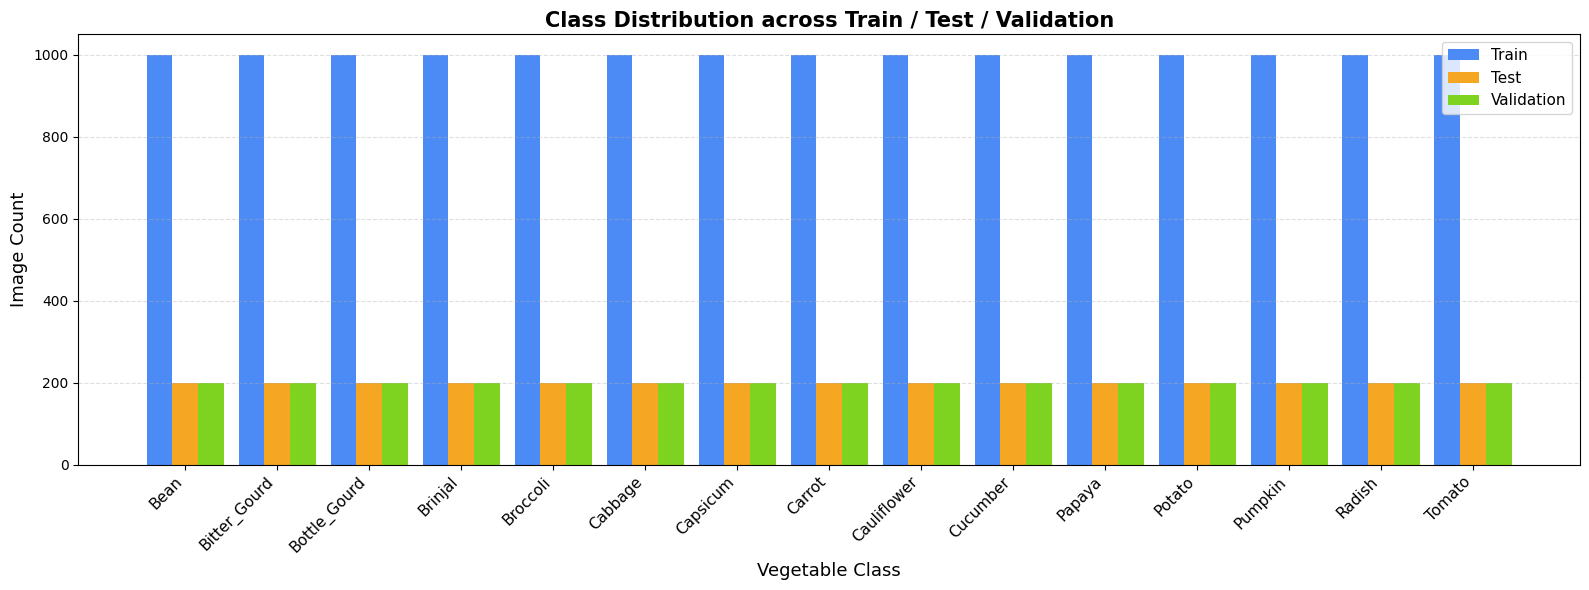

Max/Min ratio: 1.0
✅ Dataset is BALANCED — no class weighting needed.


In [33]:
vegetables = df.index.tolist()
x          = np.arange(len(vegetables))
width      = 0.28

fig, ax = plt.subplots(figsize=(16, 6))

ax.bar(x - width, df['Train Count'],      width, label='Train',      color='#4C8BF5')
ax.bar(x,         df['Test Count'],        width, label='Test',       color='#F5A623')
ax.bar(x + width, df['Validation Count'], width, label='Validation', color='#7ED321')

ax.set_xlabel('Vegetable Class', fontsize=13)
ax.set_ylabel('Image Count',     fontsize=13)
ax.set_title('Class Distribution across Train / Test / Validation', fontsize=15, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(vegetables, rotation=45, ha='right', fontsize=11)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

max_train = df['Train Count'].max()
min_train = df['Train Count'].min()
ratio     = round(max_train / min_train, 2)
print(f'Max/Min ratio: {ratio}')
if ratio <= 1.2:
    print('✅ Dataset is BALANCED — no class weighting needed.')
else:
    print('⚠️  Dataset is IMBALANCED.')

**Answer:** The dataset is perfectly balanced — each class has 1000 training images, 200 validation, and 200 test images. Max/Min ratio = 1.0

## Sample Images per Class

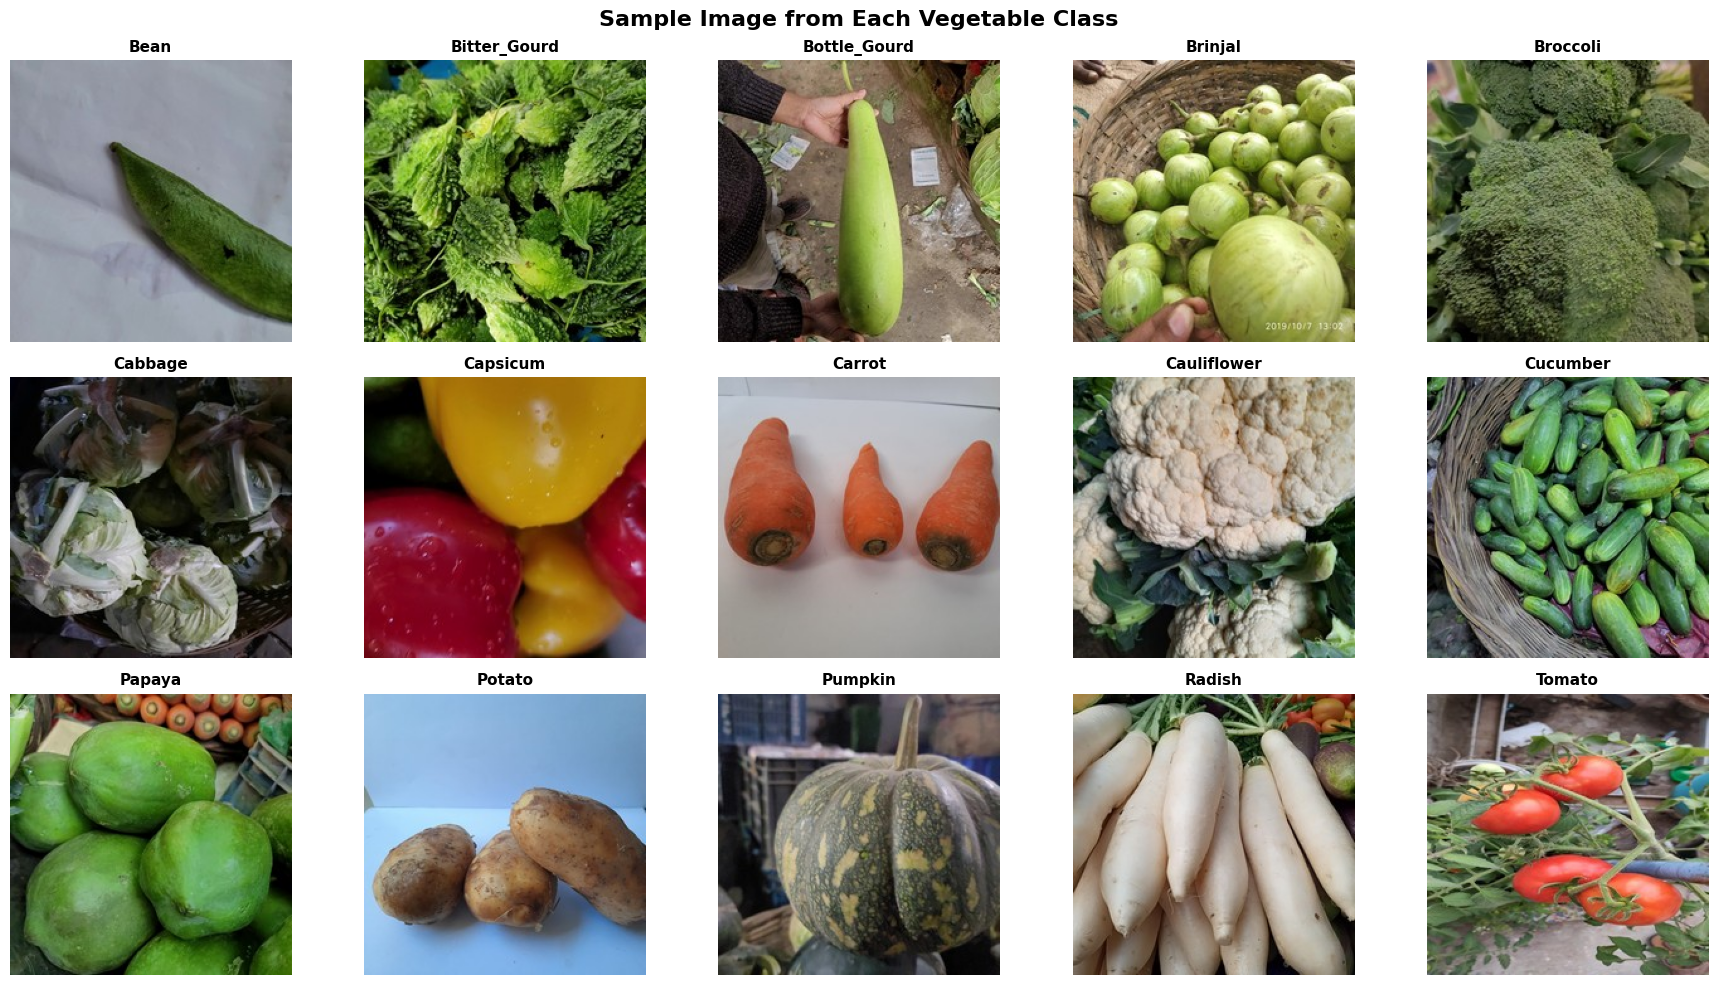

In [34]:
classes = sorted(os.listdir(TRAIN_PATH))
fig, axes = plt.subplots(3, 5, figsize=(18, 10))
axes = axes.flatten()

for i, cls in enumerate(classes):
    cls_dir  = os.path.join(TRAIN_PATH, cls)
    img_file = next(
        (f for f in os.listdir(cls_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))),
        None
    )
    if img_file:
        img = mpimg.imread(os.path.join(cls_dir, img_file))
        axes[i].imshow(img)
        axes[i].set_title(cls, fontsize=11, fontweight='bold')
        axes[i].axis('off')

plt.suptitle('Sample Image from Each Vegetable Class', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

## Part 6 + 7 — Image Generators & Augmentation

In [35]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

# Training generator — with augmentation
train_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    validation_split=0.1,
)

# Validation generator — rescale only, NO augmentation
val_datagen = ImageDataGenerator(
    rescale=1.0 / 255,
    validation_split=0.1,
)

train_ds = train_datagen.flow_from_directory(
    TRAIN_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    seed=42,
)

val_ds = val_datagen.flow_from_directory(
    VAL_PATH,
    target_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    seed=42,
)

print('Classes found:', list(train_ds.class_indices.keys()))
print('Train batches:', len(train_ds))
print('Val batches:  ', len(val_ds))

Found 13500 images belonging to 15 classes.
Found 300 images belonging to 15 classes.
Classes found: ['Bean', 'Bitter_Gourd', 'Bottle_Gourd', 'Brinjal', 'Broccoli', 'Cabbage', 'Capsicum', 'Carrot', 'Cauliflower', 'Cucumber', 'Papaya', 'Potato', 'Pumpkin', 'Radish', 'Tomato']
Train batches: 422
Val batches:   10


## Part 8 — Build CNN Model

In [36]:
NUM_CLASSES = 15

model = Sequential([
    # Block 1
    Conv2D(32,  (3, 3), activation='relu', input_shape=(*IMAGE_SIZE, 3)),
    MaxPooling2D((2, 2)),

    # Block 2
    Conv2D(64,  (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Block 3
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),

    # Fully Connected
    Flatten(),
    Dense(512, activation='relu'),
    Dropout(0.5),
    Dense(NUM_CLASSES, activation='softmax'),
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    44,302,848 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 15)             │         7,695 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 44,403,791 (169.39 MB)

 Trainable params: 44,403,791 (169.39 MB)

 Non-trainable params: 0 (0.00 B)

## Part 9 — Compile Model

In [37]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

print('Model compiled successfully ✅')
print(f'Total parameters: {model.count_params():,}')

Model compiled successfully ✅
Total parameters: 44,403,791


**Model Explanation:**
- **3 Conv Layers (32 → 64 → 128 filters):** Each block extracts increasingly complex spatial features — edges → shapes → class-specific patterns.
- **MaxPooling:** Reduces spatial size by half after each block, lowering computation while keeping the most important features.
- **Dropout (0.5):** Randomly disables 50% of neurons per training step to prevent memorisation (overfitting).
- **Softmax:** Converts final scores into probabilities across all 15 classes. The class with the highest probability is the prediction.

## Part 10 — Train Model with EarlyStopping

In [ ]:
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=20,
    callbacks=[early_stop],
    verbose=1,
)

print('\n✅ Training finished!')
print(f'Epochs trained: {len(history.history["loss"])}')

Epoch 1/20
 16/422 ━━━━━━━━━━━━━━━━━━━━ 13:31 2s/step - accuracy: 0.7114 - loss: 0.8212

**Why EarlyStopping is useful:**
Without EarlyStopping the model trains for all 20 epochs even if it starts overfitting at epoch 8.
EarlyStopping monitors `val_loss` and stops training when it does not improve for 5 consecutive epochs,
then restores the best weights automatically — saving time and preventing overfitting.

## Part 11 — Evaluate Model

In [ ]:
train_loss, train_acc = model.evaluate(train_ds, verbose=0)
val_loss,   val_acc   = model.evaluate(val_ds,   verbose=0)

print('=' * 40)
print(f'Training Accuracy:   {train_acc * 100:.2f}%')
print(f'Validation Accuracy: {val_acc   * 100:.2f}%')
print(f'Training Loss:       {train_loss:.4f}')
print(f'Validation Loss:     {val_loss:.4f}')
print('=' * 40)

diff = (train_acc - val_acc) * 100
print(f'\nAccuracy Gap: {diff:.2f}%')
if diff < 5:
    print('✅ No significant overfitting — model generalises well.')
elif diff < 15:
    print('⚠️  Mild overfitting — consider more augmentation.')
else:
    print('❌ Significant overfitting — model memorised training data.')

## Part 12 — Plot Accuracy & Loss Curves

In [ ]:
epochs_ran = range(1, len(history.history['accuracy']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Accuracy
ax1.plot(epochs_ran, history.history['accuracy'],
         label='Train Accuracy', color='#4C8BF5', linewidth=2)
ax1.plot(epochs_ran, history.history['val_accuracy'],
         label='Validation Accuracy', color='#F5A623', linewidth=2, linestyle='--')
ax1.set_title('Accuracy over Epochs', fontsize=14, fontweight='bold')
ax1.set_xlabel('Epoch',    fontsize=12)
ax1.set_ylabel('Accuracy', fontsize=12)
ax1.legend(fontsize=11)
ax1.grid(alpha=0.3)

# Loss
ax2.plot(epochs_ran, history.history['loss'],
         label='Train Loss', color='#7ED321', linewidth=2)
ax2.plot(epochs_ran, history.history['val_loss'],
         label='Validation Loss', color='#D0021B', linewidth=2, linestyle='--')
ax2.set_title('Loss over Epochs', fontsize=14, fontweight='bold')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Loss',  fontsize=12)
ax2.legend(fontsize=11)
ax2.grid(alpha=0.3)

plt.suptitle('CNN Training Curves — Vegetable Classification', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

best_epoch = int(np.argmin(history.history['val_loss'])) + 1
print(f'\n🏆 Best epoch (lowest val_loss): Epoch {best_epoch}')

## Save Model

In [ ]:
model.save('/kaggle/working/vegetable_cnn_model.h5')
print('✅ Model saved — download it from the Output panel on the right.')